# What Makes a Video Game Successful?
## An Analysis of Genre, Platform, Ratings, and Sales

This project explores historical video game data to analyze how genre, platform, critic scores, user scores, and sales relate to video game success.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In [2]:
df = pd.read_csv("../data/video_game_sales_ratings.csv")
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


## Initial Data Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
Name               16717 non-null object
Platform           16719 non-null object
Year_of_Release    16450 non-null float64
Genre              16717 non-null object
Publisher          16665 non-null object
NA_Sales           16719 non-null float64
EU_Sales           16719 non-null float64
JP_Sales           16719 non-null float64
Other_Sales        16719 non-null float64
Global_Sales       16719 non-null float64
Critic_Score       8137 non-null float64
Critic_Count       8137 non-null float64
User_Score         10015 non-null object
User_Count         7590 non-null float64
Developer          10096 non-null object
Rating             9950 non-null object
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [4]:
df.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

## Data Cleaning

In [5]:
df["User_Score"] = pd.to_numeric(df["User_Score"], errors = "coerce")
df["User_Score"].dtype

dtype('float64')

In [6]:
df_clean = df.dropna(subset = ["Name", "Genre", "Publisher", "Year_of_Release"])
df_clean.shape

(16416, 16)

In [7]:
df_clean[["Global_Sales", "Critic_Score", "User_Score"]].describe()

,Global_Sales,Critic_Score,User_Score
count,16416.000000,7982.000000,7461.000000
mean,0.536708,68.997119,7.126900
std,1.559885,13.918755,1.498886
min,0.010000,13.000000,0.000000
25%,0.060000,60.000000,6.400000
50%,0.170000,71.000000,7.500000
75%,0.470000,79.000000,8.200000
max,82.530000,98.000000,9.700000


## Sales Distribution

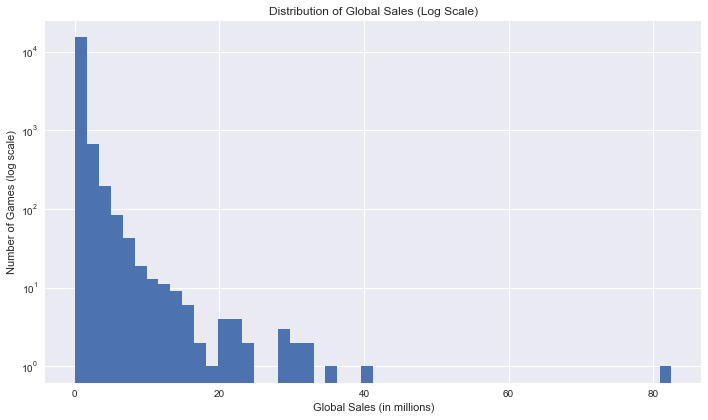

In [8]:
plt.figure(figsize=(10,6))
plt.hist(df_clean["Global_Sales"], bins=50, log=True)
plt.title("Distribution of Global Sales (Log Scale)")
plt.xlabel("Global Sales (in millions)")
plt.ylabel("Number of Games (log scale)")
plt.tight_layout()
plt.savefig("../images/global_sales_distribution_log.png", dpi=300, bbox_inches="tight")
plt.show()

## Genre Analysis

This section compares genres by total global sales and average global sales per game.

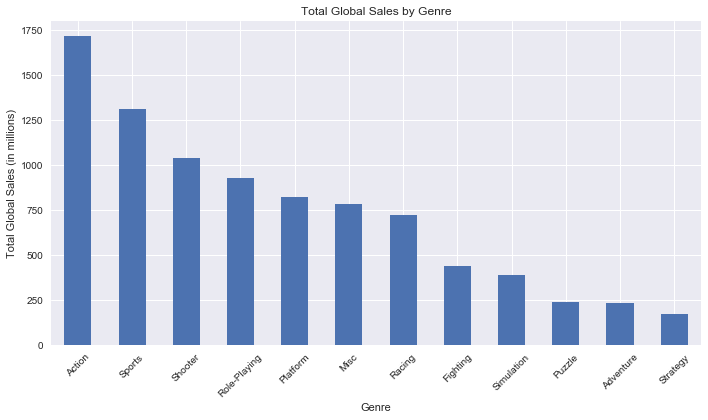

In [9]:
top_genres = df_clean.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
top_genres.plot(kind="bar")
plt.title("Total Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Global Sales (in millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/total_sales_by_genre.png", dpi=300, bbox_inches="tight")
plt.show()

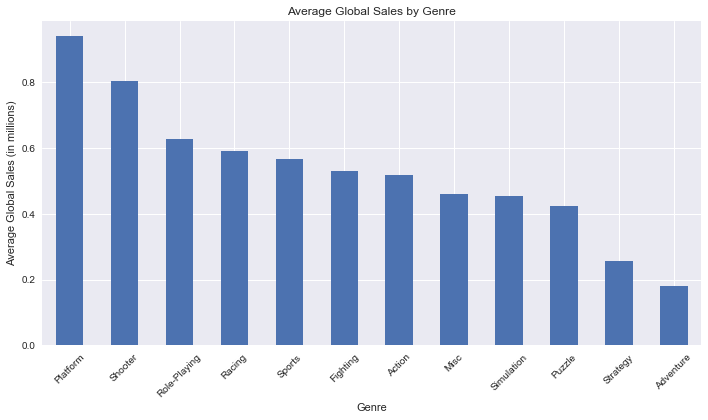

In [10]:
avg_genre_sales = df_clean.groupby("Genre")["Global_Sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
avg_genre_sales.plot(kind="bar")
plt.title("Average Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Global Sales (in millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/average_sales_by_genre.png", dpi=300, bbox_inches="tight")
plt.show()

## Platform Analysis

This section examines which platforms account for the highest total game sales in the dataset.

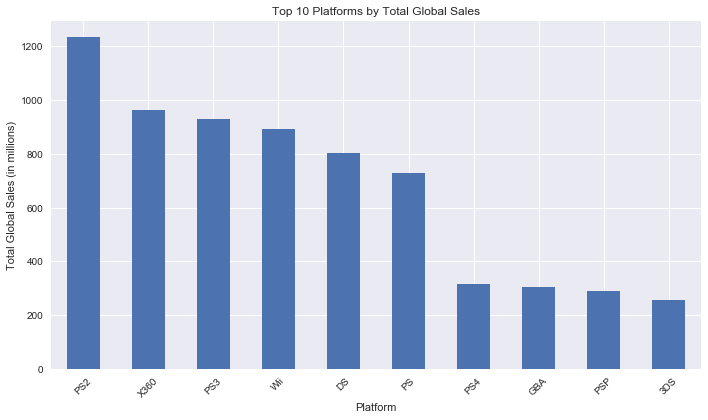

In [11]:
sales_by_platform = df_clean.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sales_by_platform.plot(kind="bar")
plt.title("Top 10 Platforms by Total Global Sales")
plt.xlabel("Platform")
plt.ylabel("Total Global Sales (in millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/top_platforms_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation
This chart shows total **video game sales by platform** within the dataset, not hardware console sales. The results are influenced by the historical coverage of the dataset, which appears to underrepresent newer platforms such as PS4.

## Review Scores and Commercial Success

This section evaluates whether critic scores and user scores are associated with global sales.

In [12]:
critic_sales = df_clean.dropna(subset = ["Critic_Score", "Global_Sales"])
critic_sales[["Critic_Score", "Global_Sales"]].corr(method="spearman")

,Critic_Score,Global_Sales
Critic_Score,1.000000,0.391921
Global_Sales,0.391921,1.000000


### Observation
The Spearman correlation between `Critic_Score` and `Global_Sales` is approximately **0.39**, indicating a moderate positive relationship.

Spearman correlation compares the **rankings** of the variables rather than their exact values. In this case, it suggests that games with higher critic scores tend to rank somewhat higher in global sales, although the relationship is not strong enough to conclude that critic scores alone explain commercial success.

In [13]:
user_sales = df_clean.dropna(subset=["User_Score", "Global_Sales"])
user_sales[["User_Score", "Global_Sales"]].corr(method = "spearman")

,User_Score,Global_Sales
User_Score,1.000000,0.149087
Global_Sales,0.149087,1.000000


### Observation
The Spearman correlation between `User_Score` and `Global_Sales` is approximately **0.15**, indicating a weak positive relationship. This suggests that games with higher user scores tend to rank slightly higher in sales, but the association is much weaker than the one observed for critic scores.

In [14]:
correlation_summary = pd.DataFrame({
    "Relationship": ["Critic_Score vs Global_Sales", "User_Score vs Global_Sales"],
    "Spearman_Correlation": [0.391921, 0.149087]
})
correlation_summary

,Relationship,Spearman_Correlation
0,Critic_Score vs Global_Sales,0.391921
1,User_Score vs Global_Sales,0.149087


### Observation
The comparison table shows that ``Critic_Score`` has a stronger relationship with `Global_Sales` than `User_Score`. In this dataset, critic ratings appear to be more closely associated with commercial success than user ratings.

## Release Trends Over Time

This section explores how the number of game releases changed over time. Years after 2016 are excluded because the dataset appears incomplete for later years.

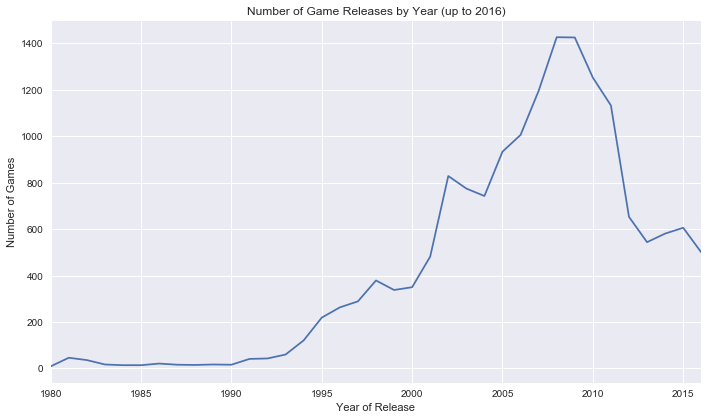

In [15]:
df_years = df_clean[df_clean["Year_of_Release"] <= 2016]
games_by_year = df_years.groupby("Year_of_Release")["Name"].count()

plt.figure(figsize=(10,6))
games_by_year.plot(kind="line")
plt.title("Number of Game Releases by Year (up to 2016)")
plt.xlabel("Year of Release")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.savefig("../images/game_releases_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation
The number of game releases increased steadily from the mid-1990s, peaked around 2008–2009, and then declined afterward in this dataset. Years after 2016 were excluded from this analysis because the dataset appears incomplete for later years, which would otherwise create a misleading drop in releases.

## Publisher Analysis

This section compares publishers by total global sales in the dataset.

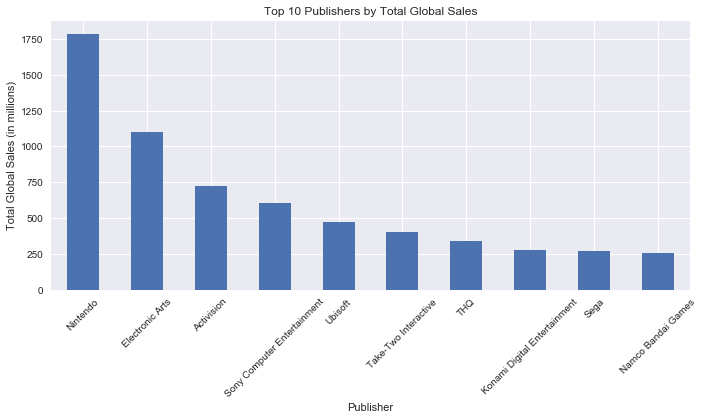

In [16]:
top_publishers = df_clean.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_publishers.plot(kind="bar")
plt.title("Top 10 Publishers by Total Global Sales")
plt.xlabel("Publisher")
plt.ylabel("Total Global Sales (in millions)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/top_publishers_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation
Nintendo has the highest total global sales among publishers in this dataset, with a large lead over Electronic Arts and Activision. This suggests that Nintendo had the strongest overall commercial presence in the dataset, although the result reflects the coverage and time period of the data rather than the complete history of the industry.

## Key Findings

- Global sales are highly skewed: most games sell relatively little, while a small number of blockbuster titles account for very high sales.
- Action games generate the highest **total** global sales in the dataset, but Platform and Shooter games perform better in terms of **average** sales per game.
- Critic scores show a **moderate positive** relationship with global sales (Spearman ≈ 0.39), suggesting that better-reviewed games tend to sell more.
- User scores show only a **weak positive** relationship with global sales (Spearman ≈ 0.15), indicating a much weaker association with commercial success.
- The number of game releases increased strongly from the mid-1990s, peaked around 2008–2009, and then declined in the dataset.
- Nintendo has the highest total global sales among publishers in this dataset, with a substantial lead over the other top publishers.

## Conclusion

This project explored historical video game sales and ratings data to better understand what factors are associated with commercial success.

The analysis showed that video game sales are highly concentrated among a small number of blockbuster titles, while most games achieve relatively low sales. Genre and platform both matter, but their impact depends on whether success is measured in total sales or average sales per game. Review scores also matter, especially critic scores, which showed a stronger relationship with sales than user scores.

Overall, the results suggest that video game success is influenced by multiple factors rather than a single variable. Genre, platform, publisher strength, and critic reception all appear to contribute, while user ratings show a weaker connection with commercial performance in this dataset.

A key limitation of the project is that the dataset is historical and appears incomplete for years after 2016, so the findings should be interpreted as patterns within this dataset rather than a complete representation of the modern video game industry.